# 1.2 Stations

Let's consider a full graph of N stations, with routes from each station to every other station, equal transit times between any two stations, but with all stations having different demand (probability of a rental).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
n_stations = 5
n_levels = 5 # How many levels of demand are there
default_demand = 0.5 # Order frequency, betweeen 0 and 1. 
                     # If too low, many runs would be wasted. If too high, total_n_orders won't be binomial.
n_steps_preparation = 30000 # For how many steps stats are NOT collected
n_steps_per_experiment = 2000
n_experiments = 100
n_cars = 20

n_steps =  n_steps_preparation + n_steps_per_experiment*n_experiments  # Full number of steps to run

demand = np.arange(n_levels, 0, -1)
demand = demand/demand.sum()
print(f"Demand values at stations: {demand}")

Demand values at stations: [0.33333333 0.26666667 0.2        0.13333333 0.06666667]


In [19]:
# Main loop

np.random.seed(1)
cm1 = np.zeros(shape=(n_experiments, n_stations))
average_cars = np.zeros(shape=(n_experiments, n_stations))
total_attempts = np.zeros(shape=(n_experiments, n_stations))
total_rentals = np.zeros(shape=(n_experiments, n_stations))

state_history = np.zeros(shape=(n_steps_per_experiment, n_stations)) # Will only remember one run

state = np.array([n_cars] + [0]*(n_stations-1)) # Case of all cars injected in the hot tile
#state = np.array([n_cars // n_stations]*n_stations) # Case of cars being distributed uniformly
state[0] = n_cars - state[1:].sum() # Only needed for uniform cas (to make sure n_cars is right)
print("Initial cars distribution across stations:", state)
i_experiment = 0
    
for i_step in range(n_steps):
    # Simulation. From each location, we only move one car at best.
    attempts = (np.random.uniform(size=n_stations) < demand) # attempts to rent a single car
    departures = attempts * (state > 0) # But the car only departs if there was a car there to begin with
    destinations = np.random.choice(
        n_stations, size=n_stations, p=np.array(demand)/sum(demand)) # Where a car would go if rented.

    destinations[~departures] = -1 # A necessary correction: if a car didn't leave, then it doesn't arrive anywhere
    arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

    state = state - departures + arrivals

    if i_step < n_steps_preparation: # Let the cars distribute
        if i_step % n_steps_per_experiment ==  0:
            print(".", end='')

    if i_step > n_steps_preparation: # Collect stats         
        cm1[i_experiment, :] += (departures + arrivals)/2/n_steps_per_experiment  # Symmetric allocation
        average_cars[i_experiment, :] += state/n_steps_per_experiment
        total_attempts[i_experiment, :] += attempts*1
        total_rentals[i_experiment, :] += departures*1

        if (n_steps - i_step) < n_steps_per_experiment: # Last run, collect data for the plot
            state_history[(i_step - n_steps_preparation) % n_steps_per_experiment, :] = state

        if (i_step - n_steps_preparation) % n_steps_per_experiment == 0:
            # Start a new data collection segment
            print("|", end='')
            i_experiment = (i_step - n_steps_preparation) // n_steps_per_experiment # Experiment counter
        
    
print("Done")

Initial cars distribution across stations: [20  0  0  0  0]
...............|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Done


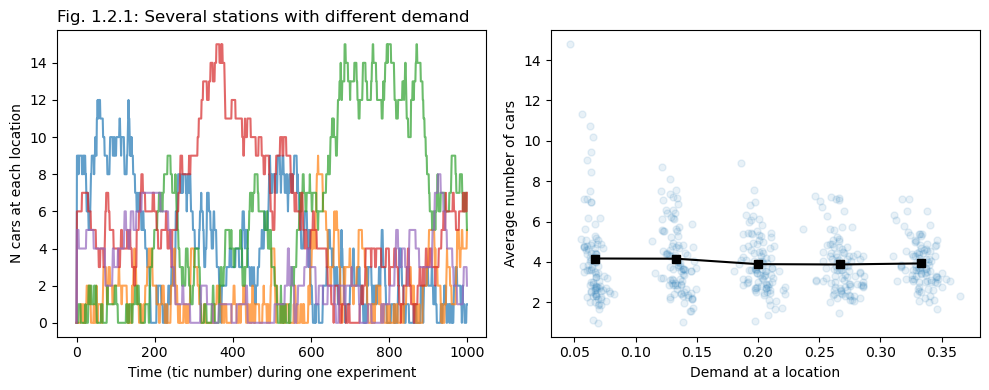

In [31]:
# Plot and save the figure

plt.figure(figsize=(10, 4), facecolor='white')
max_history = 1000

# The tracks from one (last) experiment
plt.subplot(121)
plt.title("Fig. 1.2.1: Several stations with different demand", loc='left')
plt.plot(state_history[:max_history, :], alpha=0.7);
plt.xlabel("Time (tic number) during one experiment")
plt.ylabel("N cars at each location");

# Combined results
plt.subplot(122)
#plt.plot(list(demand)*n_experiments, history.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(total_attempts.flatten()/n_steps_per_experiment, average_cars.flatten(), '.', alpha=0.1, markersize=10);
plt.plot(demand, average_cars.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("Average number of cars");

plt.tight_layout()
plt.savefig("../figures/01simple_02stations_01ncars.svg", dpi=300)

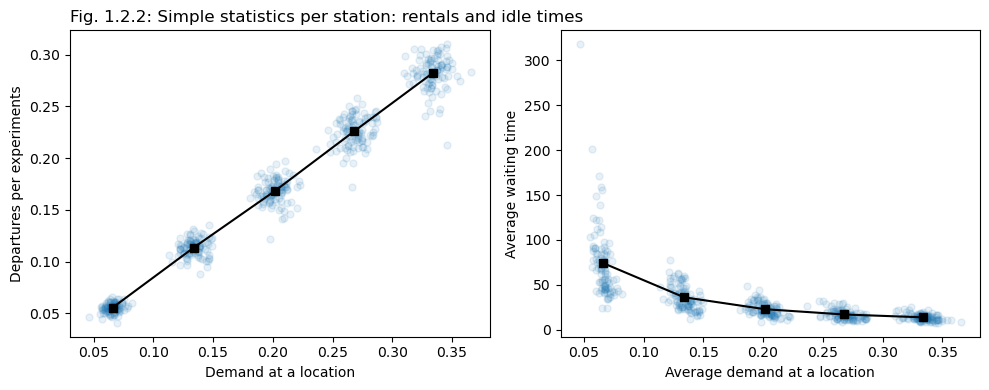

In [21]:
# Plot and save the figure

plt.figure(figsize=(10, 4), facecolor='white')

# The tracks from one (last) experiment
plt.subplot(121)
plt.title("Fig. 1.2.2: Simple statistics per station: rentals and idle times", loc='left')
x = total_attempts/n_steps_per_experiment
y = total_rentals/n_steps_per_experiment
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.1, markersize=10);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("Departures per experiments");

# Combined results
plt.subplot(122)
y = average_cars / total_rentals * n_steps_per_experiment
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.1, markersize=10);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Average demand at a location")
plt.ylabel("Average waiting time");  # Approximation
# Strictly speaking, it's not an average of idle times for individual cars, but the average ratio of
# waiting hours (time ticks) to the number of departures. They just happen to be the same ;)

plt.tight_layout()
plt.savefig("../figures/01simple_02stations_02idle.svg", dpi=300)

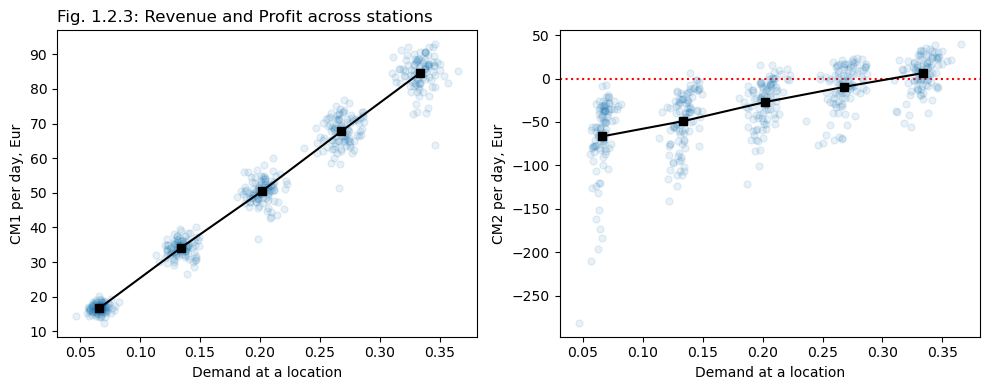

In [22]:
# Financial measures measures
cm1_factor = 20*5/max(demand)  # Assume 20 rentals/day from the hottest zone, and 5 Eur/trip in CM1
cm2_factor = 20  # Assume 20 Eur/day as a car cost

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 1.2.3: Revenue and Profit across stations", loc='left')
x = total_attempts/n_steps_per_experiment
y = cm1*cm1_factor
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.1, markersize=10);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("CM1 per day, Eur")

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
y = cm1*cm1_factor - average_cars*cm2_factor
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.1, markersize=10);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("CM2 per day, Eur")

plt.tight_layout()

plt.savefig("../figures/01simple_02stations_03financials.svg", dpi=300)

In [30]:
print("Average CM2/day:", y.sum()/n_experiments)

Average CM2/day: -146.3494999999974


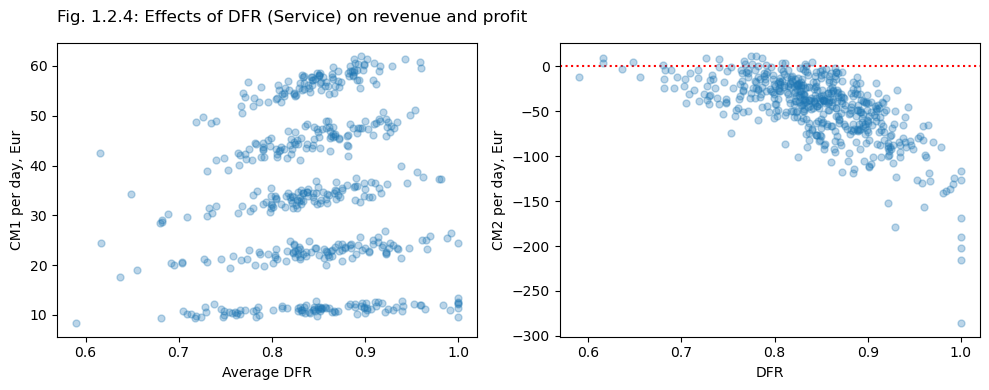

In [23]:
# DFR
dfr = total_rentals/total_attempts

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 1.2.4: Effects of DFR (Service) on revenue and profit", loc='left', pad=15)
plt.plot(dfr.flatten(), cm1.flatten()*40*5, '.', alpha=0.3, markersize=10);
plt.xlabel("Average DFR")
plt.ylabel("CM1 per day, Eur")

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
cm2 = cm1*40*5 - average_cars*20
plt.plot(dfr.flatten(), cm2.flatten(), '.', alpha=0.3, markersize=10);
plt.xlabel("DFR")
plt.ylabel("CM2 per day, Eur");

plt.tight_layout()

plt.savefig("../figures/01simple_02stations_04dfr.svg", dpi=300)